<a href="https://colab.research.google.com/github/lucasangelo40695-dotcom/CP2_SERS_CCPJ/blob/main/CP2_SERS_CCPJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Exercicio
Treinar um modelo de classificação uando um algoritmo de regressao logistica
(no sklearn ---> Logistic regression) para provar se a rede elétrica está INSTÁVEL ou ESTÁVEL

Atributo alvo (target) ---> coluna "stabf" com duas classes "stable" e "unstable"

##Preparação do ambiente

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Carregar os dados do aquivo da pasta do Github usando pandas(read_cv)

In [33]:
dados= pd.read_csv("https://raw.githubusercontent.com/lucasangelo40695-dotcom/CP2_SERS_CCPJ/refs/heads/main/Data_for_UCI_named.csv")
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [34]:
# faça uma inspeção nos dados
# quais classes existem na coluna alvo "stabf"
# quantos registros temos de cada classe?
# separar features (x) e target(y)
# separar dados de treino e teste
# instanciar o objeto "modelo" a partir da classe LogisticRegression
# treinar, gerar e avaliar

dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [42]:
#quais classes existem na coluna alvo "stabf"
dados["stabf"].unique()

array(['instável', 'estável'], dtype=object)

In [41]:
dados.stabf.value_counts()

,count
stabf,
instável,6380
estável,3620


In [43]:
# Quantos registros temos de cada classe?
dados.describe(include='object')

,stabf
count,10000
unique,2
top,instável
freq,6380


In [44]:
# Renomeando Labels
dados["stabf"]=dados["stabf"].replace({"unstable":"instável","stable":"estável"})
dados.head(6)


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,instável
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,estável
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,instável
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,instável
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,instável
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,estável


In [49]:
# separar features (x) e target(y)
dados2=dados.drop(columns="stab")
x=dados2.drop(columns="stabf")
y=dados2["stabf"]


In [50]:
# separar dados de treino e teste
x_treino,x_teste,y_treino,y_teste=train_test_split(x,y,test_size=0.3,random_state=42)

In [51]:
# instanciar o objeto "modelo" a partir da classe LogisticRegression
modelo=LogisticRegression()

In [53]:
# gerar as probabilidades
y_prob=modelo.predict_proba(x_teste)
y_prob[:50]

array([[0.04832458, 0.95167542],
       [0.06765984, 0.93234016],
       [0.32851224, 0.67148776],
       [0.9774269 , 0.0225731 ],
       [0.63944896, 0.36055104],
       [0.57932851, 0.42067149],
       [0.75220971, 0.24779029],
       [0.0253573 , 0.9746427 ],
       [0.0491907 , 0.9508093 ],
       [0.75081851, 0.24918149],
       [0.0574757 , 0.9425243 ],
       [0.45204514, 0.54795486],
       [0.56012373, 0.43987627],
       [0.2390839 , 0.7609161 ],
       [0.01632351, 0.98367649],
       [0.25307423, 0.74692577],
       [0.44524977, 0.55475023],
       [0.1910339 , 0.8089661 ],
       [0.43188331, 0.56811669],
       [0.33936356, 0.66063644],
       [0.08175104, 0.91824896],
       [0.12786239, 0.87213761],
       [0.19940876, 0.80059124],
       [0.76364784, 0.23635216],
       [0.32962162, 0.67037838],
       [0.30896806, 0.69103194],
       [0.62552247, 0.37447753],
       [0.46526131, 0.53473869],
       [0.70576222, 0.29423778],
       [0.9237145 , 0.0762855 ],
       [0.

In [54]:
# gerar as previsões
y_pred=modelo.predict(x_teste)
y_pred[:50]

array(['instável', 'instável', 'instável', 'estável', 'estável',
       'estável', 'estável', 'instável', 'instável', 'estável',
       'instável', 'instável', 'estável', 'instável', 'instável',
       'instável', 'instável', 'instável', 'instável', 'instável',
       'instável', 'instável', 'instável', 'estável', 'instável',
       'instável', 'estável', 'instável', 'estável', 'estável',
       'instável', 'estável', 'estável', 'instável', 'instável',
       'instável', 'estável', 'estável', 'instável', 'instável',
       'instável', 'instável', 'instável', 'estável', 'estável',
       'instável', 'estável', 'instável', 'estável', 'estável'],
      dtype=object)

In [57]:
# acuracia
accuracy_test = accuracy_score(y_teste, y_pred)
print(f"A acurácia do modelo é: {100 * accuracy_test:.2f}%")

A acurácia do modelo é: 80.77%


In [ ]:
# gerar a matriz de confusao, usando heatmap e seaborn

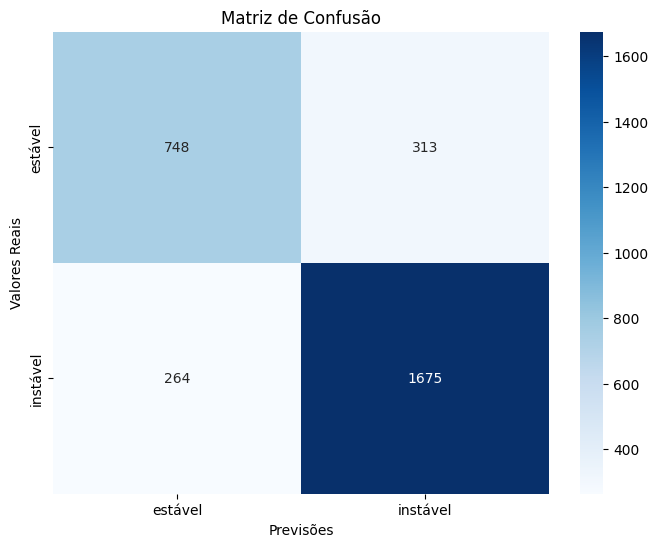

In [58]:
cm = confusion_matrix(y_teste, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Matriz de Confusão')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()